# Severity: Gamma-GLM for kostnad per skade

Notebooken modellerer forventet kostnad per registrert egen-skade med en
Gamma-GLM. Den er severity-delen av en todelt ren premie (frekvens × severity),
og bruker samme gruppe-CV og seleksjonsregel som frekvens- og Tweedie-notebookene.
Bare utviklingsårene 2022–2023 er brukt; 2024 er ikke lest.

In [1]:
from functools import partial

import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display

from src_asserts.common_glm_asserts import assert_model_definition, assert_valid_folds
from src_asserts.residual_diagnostics_asserts import assert_residual_diagnostics_result
from src_asserts.severity_asserts import (
    assert_severity_fold_contract,
    assert_severity_spec,
)
from src_core_glm.glm_core import cross_validate_glm, fit_glm, prepare_design_frame
from src_core_glm.model_data import assert_development_years, build_development_frames
from src_core_glm.model_selection import (
    build_specification,
    evaluate_models_parallel,
    propose_additions,
    propose_geography,
    propose_removals,
    propose_spline_forms,
    run_round,
    run_stepwise,
    select_candidate_stage,
)
from src_core_glm.residual_diagnostics import (
    build_residual_diagnostic_summary,
    cross_validate_residual_catboost,
    plot_residual_diagnostic_overview,
)
from src_core_glm.selection_report import (
    build_forward_selection_table,
    build_top_models_table,
)
from src_core_glm.validation import build_group_folds
from src_model_comparison.locked_models import lock_glm
from src_model_comparison.variable_coverage import build_variable_coverage
from src_severity import severity_descriptives
from src_severity.severity_data import (
    build_severity_inputs,
    summarize_severity_selection,
)

SEED = 100
N_FOLDS = 5
SE_MULTIPLIER = 1.0  # fjerde seleksjonskrav: snittgevinst > 1 standardfeil
N_JOBS = 8  # parallelle prosesser for kandidat-CV (resultatene er de samme som med 1)
GAMMA_POWER = 2  # Gamma-deviance (Tweedie-power 2)
FIT_SETTINGS = {"maxiter": 200, "tol": 1e-8}

## 1. Datagrunnlag

Responsen er gjennomsnittlig kostnad per skade i et poliseår,
$\bar X_i$ = `property_incurred` / $N_i$, der $N_i$ = `property_claims`
brukes som vekt: flere skader gir mer presis informasjon om underliggende
severity. Severity-utvalget er poliseår med minst én skade og positiv materiell
kostnad. Alle poliseår beholdes i `model_frame`, slik at modellen kan predikere
hele porteføljen.

In [2]:
# Kolonnene som er tilgjengelige for modellene. Selve modellvalget står i §4.
AVAILABLE_COLUMNS = [
    "policy_type",
    "year",
    "driver_age",
    "log_vehicle_value",
    "performance_hp_per_tonne",
    "fuel_type",
    "circulation_area",
    "municipality_type",
    "payment_frequency",
    "business_type",
    "vehicle_brand_pooled",
    "seats",
]

In [3]:
frames = build_development_frames()
development = frames["development"]
assert_development_years(development)

severity_inputs = build_severity_inputs(development, AVAILABLE_COLUMNS)
model_frame = severity_inputs["model_frame"]
severity_frame = severity_inputs["severity_frame"]

assert len(severity_frame) == 5_698
assert severity_frame["insured_id"].nunique() == 5_323
assert severity_frame["property_claims"].sum() == 9_979

display(summarize_severity_selection(model_frame, severity_frame))

,Poliseår i modellpopulasjonen,Sum eksponering,Sum registrerte skader,Positive skadeår (severity-utvalg),Unike insured_id i severity-utvalget,Sum skader i severity-utvalget,Skadevektet snittseverity (EUR),Utelatte nær-null-poliseår,Registrerte skader i utelatte år
0,55246,37126.013699,9989,5698,5323,9979,872.64457,9,10


## 2. Validering

Gamma-deviance beregnes out-of-fold og vektes med $N_i$. Fem gruppefolder på
`insured_id` hindrer at samme forsikrede finnes i både trening og validering.
Foldene bygges på hele modellpopulasjonen (som i frekvens og Tweedie). Modellen
fittes og scores på positive skadeår, men predikerer alle poliseår i
valideringsfolden, slik at frekvens × severity kan beregnes for hele porteføljen.

In [4]:
cv_folds = build_group_folds(
    model_frame,
    group_column="insured_id",
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=SEED,
)
assert_valid_folds(cv_folds, model_frame)  # sanity-sjekk, kan fjernes

## 3. Modellspesifikasjon

$$
\bar X_i \sim \operatorname{Gamma}(\mu_i, \phi/N_i),
\qquad
\log\mu_i = \beta_0 + \sum_j f_j(x_{ij}).
$$

Her er $\bar X_i$ gjennomsnittskostnad per skade, $N_i$ antall registrerte skader
og $f_j$ enten lineær ($\beta_j x_{ij}$) eller en naturlig kubisk spline. Med
$\operatorname{Var}(\bar X_i)=\phi\,\mu_i^2/N_i$ (Tweedie-power 2) er $N_i$
`var_weights`. Modellen har ingen interaksjoner.

In [5]:
# Hvilke variabler som er hva. Seleksjonen under leser bare disse listene.
LOCKED = ["policy_type", "year"]  # alltid med, fjernes aldri
CORE = ["municipality_type", "log_vehicle_value", "driver_age"]  # startmodell K0
GEOGRAPHY = "circulation_area"  # testes mot og sammen med municipality_type
ADDITIONAL = [  # tillegg: legges til én om gangen, så lenge de forbedrer modellen
    "performance_hp_per_tonne",
    "fuel_type",
    "payment_frequency",
    "business_type",
    "vehicle_brand_pooled",
    "seat_category",
]
SPLINE_ADDITIONS = {"performance_hp_per_tonne": 3}  # ytelse testes også som spline

# En modell er en liste med termer (kolonne) og eventuelle splines.
definitions = {"K0": {"terms": [*LOCKED, *CORE], "splines": {}}}

In [6]:
# Referansenivåer: endrer ikke deviancen, bare hva koeffisientene måles mot.
BASE_LEVELS = {
    "policy_type": "COMP_E",
    "year": 2022,
    "municipality_type": "I",
    "circulation_area": "U",
    "seat_category": "=5",
    "fuel_type": "D",
    "business_type": "NB",
    "payment_frequency": "A",
}
SEVERITY_SETTINGS = {
    "y": "average_severity",
    "family": sm.families.Gamma(sm.families.links.Log()),
    "weight": "property_claims",
    "power": GAMMA_POWER,
    "base_level_overrides": BASE_LEVELS,
}


def build_severity_specification(name, definition):
    """Bygg Gamma-spesifikasjonen (log-link, skadeantall som vekt) på severity-utvalget."""
    return build_specification(name, definition, severity_frame, SEVERITY_SETTINGS)


assert_severity_spec(
    build_severity_specification("K0", definitions["K0"])
)  # kan fjernes

## 4. Sammenligning og valg

Alle trinn bruker den samme firleddsregelen: en kandidat velges bare hvis den har
**lavere pooled OOF-deviance** enn foreldremodellen, er **bedre i minst fire av
fem folder**, har **gyldig fit i alle folder** og har en **snittgevinst over én
standardfeil**. Med $d_k$ = foreldrens minus kandidatens deviance i fold $k$ er
siste krav

$$\bar d > \frac{s_d}{\sqrt{5}}, \qquad \bar d = \tfrac15\sum_k d_k.$$

Kravet er et grovt støyfilter mot små, tilfeldige gevinster, ikke en formell test.

| Trinn | Type | Kandidater |
|---|---|---|
| 4.2–4.3 Funksjonsform | ett valg | alder: spline df 2, 3, 4; bilverdi: spline df 3 |
| 4.4 Geografi | ett valg | `municipality_type` i stedet for, eller i tillegg til, `circulation_area` |
| 4.5 Tillegg | forover-løkke | `ADDITIONAL`, én om gangen til ingen består; ytelse også som spline (df 3) |
| 4.6 Ablasjon | bakover-løkke | alle termer unntatt `LOCKED` |

### 4.1 Evaluering av startmodellen K0

Gamma-deviance ($p=2$) er fastlagt av familien, så ingen power skal velges.
Cellen under definerer evaluering, parallell kandidat-CV og seleksjonsregelen,
og gir startmodellen K0 (låste variabler + kjerne, lineære) sin første CV-score.

In [7]:
cv_results, specifications = {}, {}


def evaluate_model(name):
    """Bygg spesifikasjonen og kjør CV for én modelldefinisjon."""
    assert_model_definition(definitions[name], LOCKED)  # sanity-sjekk, kan fjernes
    specification = build_severity_specification(name, definitions[name])
    result = cross_validate_glm(
        specification,
        severity_frame,
        cv_folds,
        prediction_data=model_frame,
        fit_kwargs=FIT_SETTINGS,
    )
    if result["valid"]:  # sanity-sjekk, kan fjernes
        assert_severity_fold_contract(result, model_frame, severity_frame, cv_folds)
    return specification, result


def evaluate_models(names):
    """Kjør CV for flere modelldefinisjoner parallelt (én prosess per kandidat)."""
    evaluate_models_parallel(evaluate_model, specifications, cv_results, N_JOBS, names)


# Firleddsregelen med Gamma-deviance; kalles som select_stage(foreldre, kandidatnavn).
select_stage = partial(
    select_candidate_stage,
    cv_results,
    response=severity_frame["average_severity"],
    sample_weight=severity_frame["property_claims"],
    power=GAMMA_POWER,
    se_multiplier=SE_MULTIPLIER,
)

evaluate_models(["K0"])

### 4.2 Funksjonsform: alder

Lineær alder (K0) utfordres av naturlig kubisk spline med 2, 3 og 4
frihetsgrader. Bare én aldersform kan velges.

In [8]:
core = definitions["K0"]
age_alternatives = propose_spline_forms(core, "driver_age", "alder", (2, 3, 4))
age_model, age_table = run_round(
    "K0", age_alternatives, definitions, evaluate_models, select_stage
)
display(age_table.round(4))
print(f"Valgt etter aldersform: {age_model}")

,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,snitt_gevinst,se_gevinst,gevinst_over_se,cv_feil,endring,valgt
modell,,,,,,,,,,
K0+alder_df2,0.7285,False,False,True,-0.0002,0.0004,False,,+alder_df2,False
K0+alder_df3,0.7290,False,False,True,-0.0007,0.0007,False,,+alder_df3,False
K0+alder_df4,0.7285,False,False,True,-0.0002,0.0008,False,,+alder_df4,False


Valgt etter aldersform: K0


### 4.3 Funksjonsform: bilverdi

`log_vehicle_value` utfordres av en spline med 3 frihetsgrader.

In [9]:
current = definitions[age_model]
value_alternatives = propose_spline_forms(
    current, "log_vehicle_value", "bilverdi", (3,)
)
value_model, value_table = run_round(
    age_model, value_alternatives, definitions, evaluate_models, select_stage
)
display(value_table.round(4))
print(f"Valgt etter bilverdi: {value_model}")

,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,snitt_gevinst,se_gevinst,gevinst_over_se,cv_feil,endring,valgt
modell,,,,,,,,,,
K0+bilverdi_df3,0.7289,False,False,True,-0.0006,0.0005,False,,+bilverdi_df3,False


Valgt etter bilverdi: K0


### 4.4 Geografi

`municipality_type` (I/C/IS) er med i kjernen. `circulation_area` (U/R) testes
enten *i stedet for* `municipality_type` eller *i tillegg til* den. Bare ett
alternativ kan velges.

In [10]:
current = definitions[value_model]
geography_alternatives = propose_geography(current, GEOGRAPHY, "municipality_type")
geography_model, geography_table = run_round(
    value_model, geography_alternatives, definitions, evaluate_models, select_stage
)
display(geography_table.round(4))
print(f"Valgt etter geografi: {geography_model}")

,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,snitt_gevinst,se_gevinst,gevinst_over_se,cv_feil,endring,valgt
modell,,,,,,,,,,
K0+circulation_area,0.7270,True,False,True,0.0012,0.0021,False,,+circulation_area,False
K0_bytt_til_circulation_area,0.7248,True,True,True,0.0034,0.0014,True,,_bytt_til_circulation_area,True


Valgt etter geografi: K0_bytt_til_circulation_area


### 4.5 Tillegg

Forover-seleksjon: beste tillegg som består regelen legges til, og de
gjenstående testes på nytt mot den nye modellen, til ingen består. Ytelse
(`performance_hp_per_tonne`) testes både lineært og som spline (df 3); bare én
av formene kan velges.

In [11]:
additions_model, additions_table = run_stepwise(
    geography_model,
    propose_additions(ADDITIONAL, SPLINE_ADDITIONS),
    definitions,
    evaluate_models,
    select_stage,
)
display(additions_table.round(4))
print(f"Valgt etter tillegg: {additions_model}")

,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,snitt_gevinst,se_gevinst,gevinst_over_se,cv_feil,endring,valgt,runde
modell,,,,,,,,,,,
K0_bytt_til_circulation_area+performance_hp_per_tonne,0.7256,False,False,True,-0.0008,0.0007,False,,+performance_hp_per_tonne,False,1
K0_bytt_til_circulation_area+performance_hp_per_tonne_df3,0.7263,False,False,True,-0.0014,0.0009,False,,+performance_hp_per_tonne_df3,False,1
K0_bytt_til_circulation_area+fuel_type,0.7263,False,False,True,-0.0014,0.0006,False,,+fuel_type,False,1
K0_bytt_til_circulation_area+payment_frequency,0.7251,False,False,True,-0.0002,0.0003,False,,+payment_frequency,False,1
K0_bytt_til_circulation_area+business_type,0.7237,True,True,True,0.0011,0.0007,True,,+business_type,True,1
K0_bytt_til_circulation_area+vehicle_brand_pooled,0.7280,False,False,True,-0.0033,0.0035,False,,+vehicle_brand_pooled,False,1
K0_bytt_til_circulation_area+seat_category,0.7237,True,False,True,0.0012,0.0010,True,,+seat_category,False,1
K0_bytt_til_circulation_area+business_type+performance_hp_per_tonne,0.7244,False,False,True,-0.0007,0.0007,False,,+performance_hp_per_tonne,False,2
K0_bytt_til_circulation_area+business_type+performance_hp_per_tonne_df3,0.7251,False,False,True,-0.0014,0.0008,False,,+performance_hp_per_tonne_df3,False,2


Valgt etter tillegg: K0_bytt_til_circulation_area+business_type


### 4.6 Ablasjon

Bakover-løkke: én term (unntatt `LOCKED`) fjernes om gangen, og fjerningen
beholdes bare når den oppfyller samme firleddsregel. Gjentas til ingen består.

In [12]:
final_model, ablation_table = run_stepwise(
    additions_model,
    propose_removals(set(LOCKED)),
    definitions,
    evaluate_models,
    select_stage,
)
display(ablation_table.round(4))
print(f"Valgt etter ablasjon: {final_model}")

,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,snitt_gevinst,se_gevinst,gevinst_over_se,cv_feil,endring,valgt,runde
modell,,,,,,,,,,,
K0_bytt_til_circulation_area+business_type-circulation_area,0.7250,False,False,True,-0.0012,0.0018,False,,-circulation_area,False,1
K0_bytt_til_circulation_area+business_type-log_vehicle_value,0.7286,False,False,True,-0.0047,0.0046,False,,-log_vehicle_value,False,1
K0_bytt_til_circulation_area+business_type-driver_age,0.7233,True,False,True,0.0004,0.0004,True,,-driver_age,False,1
K0_bytt_til_circulation_area+business_type-business_type,0.7248,False,False,True,-0.0011,0.0007,False,,-business_type,False,1


Valgt etter ablasjon: K0_bytt_til_circulation_area+business_type


### 4.7 Forover-seleksjon: hva tilfører verdi?

Én rad per valgt steg (§4.2–4.5). `oof_deviance` er pooled OOF etter steget,
`snitt_gevinst` og `se_gevinst` er snitt og standardfeil av fold-gevinstene mot
foreldremodellen, og `gevinst_i_se` er forholdet mellom dem. Rundt 1 er
marginalt: når mange kandidater sammenlignes, ligger den beste ofte på 1–1,5 SE
selv uten reelt signal.

In [13]:
display(
    build_forward_selection_table(
        [age_table, value_table, geography_table, additions_table]
    ).round(4)
)
assert_model_definition(definitions[final_model], LOCKED)  # sanity-sjekk, kan fjernes
print("Valgt severity-modell:", definitions[final_model])

,endring,oof_deviance,snitt_gevinst,se_gevinst,gevinst_i_se
steg,,,,,
1,_bytt_til_circulation_area,0.7248,0.0034,0.0014,2.5313
2,+business_type,0.7237,0.0011,0.0007,1.5862


Valgt severity-modell: {'terms': ['policy_type', 'year', 'circulation_area', 'log_vehicle_value', 'driver_age', 'business_type'], 'splines': {}}


### 4.8 Konkurrerende modeller

De tre evaluerte modellene med lavest pooled OOF-deviance. `endring` viser hva som
skiller dem fra den valgte modellen, `parametere` er antall koeffisienter
(inkludert konstantledd) og `delta_mot_valgt` er OOF-deviance minus den valgtes
(negativ = lavere). Er en enklere modell praktisk talt like god, er den å
foretrekke; en mer kompleks modell er bare interessant hvis forskjellen er
tydelig over støyen i §4.7.

In [14]:
top_models = build_top_models_table(
    cv_results,
    definitions,
    final_model,
    severity_frame["average_severity"],
    severity_frame["property_claims"],
    GAMMA_POWER,
)
with pd.option_context("display.max_colwidth", None):
    display(top_models.reset_index(drop=True).round(4))

,endring,variabler,parametere,oof_deviance,delta_mot_valgt
0,+ seat_category,"policy_type, year, circulation_area, log_vehicle_value, driver_age, business_type, seat_category",9,0.7225,-0.0011
1,− driver_age,"policy_type, year, circulation_area, log_vehicle_value, business_type",6,0.7233,-0.0004
2,+ seat_category − business_type,"policy_type, year, circulation_area, log_vehicle_value, driver_age, seat_category",8,0.7237,-0.0000


### 4.9 Endelig modell

Den valgte modellen er en Gamma-GLM med log-link og skadeantall som vekt:

$$
\bar X_i \sim \operatorname{Gamma}(\mu_i,\phi/N_i),
\qquad
\log\mu_i = \beta_0
+ \beta_1\,\mathrm{CompN}_i
+ \beta_2\,\mathrm{Y2023}_i
+ \beta_3\,\mathrm{Rural}_i
+ \beta_4\,\mathrm{BizP}_i
+ \beta_5\,\log V_i
+ \beta_6\,\mathrm{Age}_i.
$$

Referansenivåer: `policy_type` = COMP_E (indikator $\mathrm{CompN}$ for COMP_N),
`year` = 2022 ($\mathrm{Y2023}$), `circulation_area` = U ($\mathrm{Rural}$ for R)
og `business_type` = NB ($\mathrm{BizP}$ for P). $V_i$ er `vehicle_value` (så
$\log V_i$ = `log_vehicle_value`) og $\mathrm{Age}_i$ er `driver_age`; begge er
lineære. Modellen har 7 parametere (konstantledd og 6 koeffisienter) i tillegg til
dispersjonen $\phi$. Den estimeres på hele severity-utvalget (2022–2023) med
cluster-robuste standardfeil på `insured_id`.

In [15]:
# Sikrer at notebooken og formelen over ikke driver fra hverandre.
final_specification = specifications[final_model]
assert definitions[final_model]["terms"] == [
    "policy_type",
    "year",
    "circulation_area",
    "log_vehicle_value",
    "driver_age",
    "business_type",
]
assert definitions[final_model]["splines"] == {}

In [16]:
final_design = prepare_design_frame(
    severity_frame, severity_frame, final_specification["required_columns"]
)
final_fit = fit_glm(
    final_specification,
    final_design,
    cluster_groups=final_design["insured_id"],
    fit_kwargs=FIT_SETTINGS,
)
assert len(final_fit.params) == 7
display(final_fit.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:       average_severity   No. Observations:                 5698
Model:                            GLM   Df Residuals:                     5691
Model Family:                   Gamma   Df Model:                            6
Link Function:                    Log   Scale:                          3.0960
Method:                          IRLS   Log-Likelihood:                -46419.
Date:                Sat, 19 Sep 2026   Deviance:                       7169.4
Time:                        18:40:50   Pearson chi2:                 1.76e+04
No. Iterations:                    11   Pseudo R-squ. (CS):            0.02865
Covariance Type:              cluster                                         
=================================================================================================================
                                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
Intercept                                         4.8831      0.376     12.970      0.000       4.145       5.621
C(policy_type, Treatment('COMP_E'))[T.COMP_N]    -0.3951      0.031    -12.894      0.000      -0.455      -0.335
C(year, Treatment(2022))[T.2023]                 -0.0495      0.036     -1.370      0.171      -0.120       0.021
C(circulation_area, Treatment('U'))[T.R]          0.1017      0.033      3.038      0.002       0.036       0.167
C(business_type, Treatment('NB'))[T.P]           -0.0831      0.033     -2.529      0.011      -0.147      -0.019
log_vehicle_value                                 0.2043      0.036      5.605      0.000       0.133       0.276
driver_age                                       -0.0011      0.001     -0.919      0.358      -0.004       0.001
=================================================================================================================
"""

## 5. Kostnadsfordeling og storskader

Figuren viser kostnadskonsentrasjon og fordelingen av gjennomsnittskostnad per
skadeår. Den er diagnostisk: skadeårene er ikke enkeltskader, og verken terskler
eller kapping brukes i modellen.

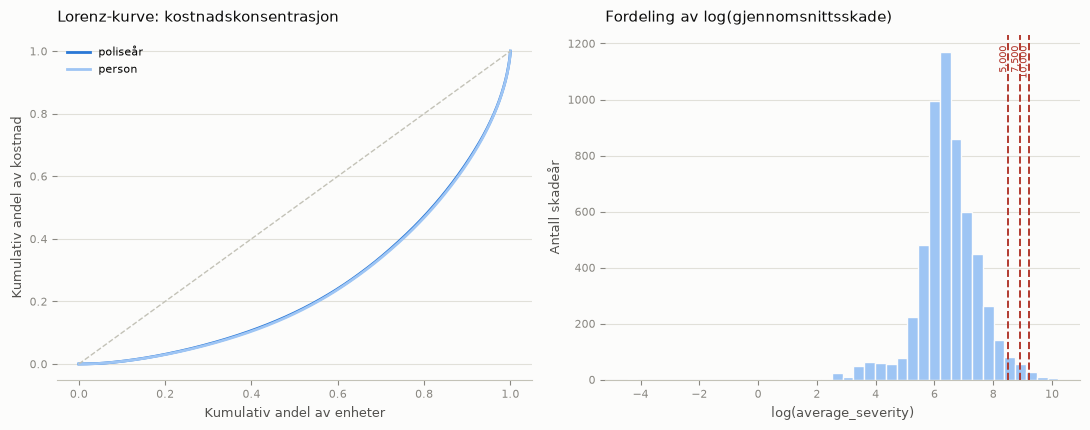

In [17]:
display(severity_descriptives.plot_cost_concentration(severity_frame))

## 6. Relativiteter for valgt modell

Koeffisientene fra §4.9 som relativiteter, $e^{\hat\beta}$, med 95 %
konfidensintervall fra de cluster-robuste standardfeilene. De er justerte
sammenhenger i dette datasettet, ikke kausale effekter.

In [18]:
confidence = final_fit.conf_int()
coefficient_table = pd.DataFrame(
    {
        "ledd": final_fit.params.index,
        "koeffisient": final_fit.params.to_numpy(),
        "SE_cluster": final_fit.bse.to_numpy(),
        "relativitet": np.exp(final_fit.params.to_numpy()),
        "relativitet_lav": np.exp(confidence[0].to_numpy()),
        "relativitet_høy": np.exp(confidence[1].to_numpy()),
    }
)
display(coefficient_table.round(3))

,ledd,koeffisient,SE_cluster,relativitet,relativitet_lav,relativitet_høy
0,Intercept,4.883,0.376,132.040,63.131,276.163
1,"C(policy_type, Treatment('COMP_E'))[T.COMP_N]",-0.395,0.031,0.674,0.634,0.715
2,"C(year, Treatment(2022))[T.2023]",-0.049,0.036,0.952,0.887,1.022
3,"C(circulation_area, Treatment('U'))[T.R]",0.102,0.033,1.107,1.037,1.182
4,"C(business_type, Treatment('NB'))[T.P]",-0.083,0.033,0.920,0.863,0.981
5,log_vehicle_value,0.204,0.036,1.227,1.142,1.318
6,driver_age,-0.001,0.001,0.999,0.997,1.001


## 7. CatBoost-diagnostikk av residualstruktur

Finnes det struktur i forventet kostnad som den valgte Gamma-GLM-en ikke fanger?
CatBoost er kun en diagnose og velger aldri GLM-variabler.

$$
z_i=\frac{y_i}{\hat\mu_{i,\mathrm{inner\ OOF}}},
\qquad
a_i=w_i\,\hat\mu_{i,\mathrm{inner\ OOF}}^{\,2-p},
\qquad
\hat\mu_i^*=\hat\mu_{i,\mathrm{GLM}}\,\hat h(x_i).
$$

Her er $y_i$ gjennomsnittskostnad, $w_i=N_i$ skadeantall og $p=2$ (Gamma), så
$a_i=w_i$. $z_i$ er observert kostnad relativt til GLM-prediksjonen (rundt 1
hvis GLM-en treffer) og $\hat h(x)$ er CatBoosts korreksjonsfaktor lært med
Poisson-loss. **Indre CV** (fem nye `insured_id`-folder inne i hver ytre
treningsdel) lager $z_i$, så CatBoost aldri trener på prediksjoner fra en GLM
som har sett raden. **Ytre CV** måler gevinsten på forsikrede CatBoost ikke
har sett. Dybde 1 er additiv, dybde 3 kan også fange interaksjoner. Bare de
positive severity-radene brukes.

In [19]:
residual_diagnostics = cross_validate_residual_catboost(
    final_specification,
    severity_frame,
    cv_folds,  # bygget på model_frame og skjæres mot severity_frame
    final_specification["required_columns"],
    categorical_columns=tuple(final_specification["base_levels"]),
    blocked_feature_columns=("property_incurred",),  # kostnaden er responsen
    fit_kwargs=FIT_SETTINGS,
    seed=SEED,
)
assert_residual_diagnostics_result(
    residual_diagnostics, severity_frame, cv_folds
)  # kan fjernes

### 7.1 Finnes det residualstruktur?

GLM-en sammenlignes med en konstant korreksjon (bare nivå) og to CatBoost-dybder,
med Gamma-deviance på alle OOF-rader. `delta_*` er reduksjon i deviance
(positivt er bedre), `better_than_*_folds` teller ytre folder med gevinst og
`oof_ae` er faktisk delt på predikert kostnad.

In [20]:
display(build_residual_diagnostic_summary(residual_diagnostics).round(4))

,benchmark,pooled_oof_deviance,delta_vs_glm,relative_gain_vs_glm,delta_vs_constant,delta_vs_depth_1,better_than_glm_folds,better_than_constant_folds,better_than_depth_1_folds,oof_ae,valid
0,glm,0.7237,0.0000,0.0000,0.0000,NaN,0,3,NaN,1.0002,True
1,constant,0.7237,-0.0000,-0.0000,0.0000,NaN,2,0,NaN,0.9984,True
2,catboost_depth_1,0.7238,-0.0001,-0.0002,-0.0001,NaN,2,2,NaN,1.0005,True
3,catboost_depth_3,0.7259,-0.0022,-0.0030,-0.0021,-0.002,1,1,0.0,1.0011,True


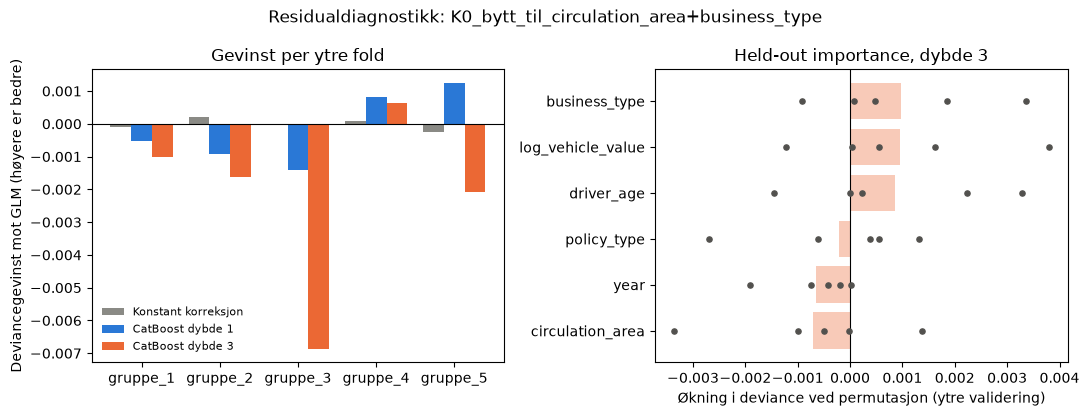

In [21]:
residual_overview_figure = plot_residual_diagnostic_overview(residual_diagnostics)

## 8. Variabelsjekk og låst modell

Variabelsjekken viser at hver tilgjengelig variabel er testet i kandidatregisteret,
og at alle øvrige kolonner bevisst er utelatt med begrunnelse. Deretter lagres den
endelige modellen (allerede fittet på alle utviklingsdata) som `models/severity.joblib`,
lastes på nytt og kontrolleres mot notebookens egne prediksjoner.

In [22]:
tested_terms = [*LOCKED, *CORE, GEOGRAPHY, *ADDITIONAL]
variable_coverage = build_variable_coverage(
    development,
    AVAILABLE_COLUMNS,
    tested_terms,
    final_specification["required_columns"],
)
display(variable_coverage)

,variabel,status,begrunnelse
0,year,i endelig modell,
1,policy_type,i endelig modell,
2,policy_status,utelatt,ukjent om status er kjent ved periodestart
3,business_type,i endelig modell,
4,payment_frequency,"testet, ikke valgt",
5,bonus_score,utelatt,tidspunkt for fastsettelse uavklart (lekkasjer...
6,driver_age,i endelig modell,
7,vehicle_age,utelatt,uklar betydning i kildedokumentasjonen
8,age_driving_licence,utelatt,rå verdi; erstattet av utledet erfaring
9,fuel_type,"testet, ikke valgt",


In [23]:
display(lock_glm("severity", final_specification, final_fit, final_design, development))

,modell,fil,størrelse_MB,rader_kontrollert,snitt_prediksjon
0,severity,models/severity.joblib,3.03,3976,893.321043


## 9. Begrensninger

Modellen predikerer forventet kostnad per skade; todelt ren premie er
frekvens × severity og settes sammen i en annen notebook.

- **Optimistisk utviklingsscore.** Samme fem folder brukes til alle valg
  (funksjonsform, geografi, tillegg, ablasjon), så OOF-deviance er ikke en
  uavhengig test. Forskjellene mellom de beste kandidatene er små (§4.8), og
  tillegget `business_type` ligger bare på rundt 1,6 standardfeil (§4.7).
- **Lite data, stor spredning.** 5 698 skadeår (9 979 skader) og en
  Gamma-dispersjon rundt 3,1 gir lav statistisk styrke. At CatBoost ikke gir
  gevinst (§7) er derfor ikke bevis for fravær av struktur.
- **Forutsetninger.** Gamma med konstant variasjonskoeffisient ($\operatorname{Var}
  \propto \mu^2/N$), log-link og additive, lineære effekter; spline for alder og
  bilverdi ble ikke valgt, og ingen interaksjoner er testet. Skadeantall som vekt
  antar at et poliseår med flere skader gir proporsjonalt mer informasjon.
- **Ingen kapping eller storskadebehandling.** Modellen kan påvirkes av enkelte
  svært store skader (§5). 10 av 9 989 registrerte skader ligger i utelatte
  nær-null-poliseår og teller ikke i severity (men i frekvens).
- **Årseffekt.** `year` er en låst kategorisk term og 2024 finnes ikke i
  treningsdata, så 2024 skåres med 2023-nivået (ingen trend-ekstrapolering;
  årsdrift blir liggende i porteføljebalansen).
- **Utenfor treningsområdet.** Numeriske prediktorer klippes til
  treningsområdet ved skåring (se `src_model_comparison/locked_models.py`).